In [30]:
import pandas as pd

In [31]:
df = pd.read_csv("../datasets/exams.csv")

In [32]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,male,group E,associate's degree,standard,completed,79,75,81
1,female,group C,associate's degree,free/reduced,none,56,65,64
2,male,group D,bachelor's degree,standard,none,86,68,74
3,female,group A,bachelor's degree,standard,none,68,78,76
4,female,group D,high school,free/reduced,none,49,68,61


In [33]:
df.dtypes


gender                         object
race/ethnicity                 object
parental level of education    object
lunch                          object
test preparation course        object
math score                      int64
reading score                   int64
writing score                   int64
dtype: object

In [34]:
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [35]:
df.select_dtypes(include=['number']).mean()

math score       65.06
reading score    67.28
writing score    66.47
dtype: float64

In [36]:
from sklearn.preprocessing import scale

In [37]:
for col in df.select_dtypes(include=['number']).columns:
    df[col] = scale(df[col])

In [38]:
df.select_dtypes(include=['number']).std()

math score       1.005038
reading score    1.005038
writing score    1.005038
dtype: float64

In [39]:
from sklearn.preprocessing import LabelEncoder

In [40]:
enc = LabelEncoder()
df["gender"] = enc.fit_transform(df['gender'].astype(str))

In [41]:
enc.classes_

array(['female', 'male'], dtype=object)

In [42]:
df["race/ethnicity"].value_counts()

race/ethnicity
group C    32
group B    27
group D    20
group A    11
group E    10
Name: count, dtype: int64

In [43]:
df = pd.get_dummies(df, columns=['race/ethnicity', 'parental level of education', 'lunch', "test preparation course"], dtype=int)

In [44]:
df.shape

(100, 19)

In [45]:
df.head()

,gender,math score,reading score,writing score,race/ethnicity_group A,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E,parental level of education_associate's degree,parental level of education_bachelor's degree,parental level of education_high school,parental level of education_master's degree,parental level of education_some college,parental level of education_some high school,lunch_free/reduced,lunch_standard,test preparation course_completed,test preparation course_none
0,1,0.994557,0.574138,1.049901,0,0,0,0,1,1,0,0,0,0,0,0,1,1,0
1,0,-0.646391,-0.169564,-0.178476,0,0,1,0,0,1,0,0,0,0,0,1,0,0,1
2,1,1.493976,0.053547,0.544099,0,0,0,1,0,0,1,0,0,0,0,0,1,0,1
3,0,0.209756,0.797248,0.688613,1,0,0,0,0,0,1,0,0,0,0,0,1,0,1
4,0,-1.145810,0.053547,-0.395248,0,0,0,1,0,0,0,1,0,0,0,1,0,0,1


In [47]:
df.dtypes

gender                                              int64
math score                                        float64
reading score                                     float64
writing score                                     float64
race/ethnicity_group A                              int64
race/ethnicity_group B                              int64
race/ethnicity_group C                              int64
race/ethnicity_group D                              int64
race/ethnicity_group E                              int64
parental level of education_associate's degree      int64
parental level of education_bachelor's degree       int64
parental level of education_high school             int64
parental level of education_master's degree         int64
parental level of education_some college            int64
parental level of education_some high school        int64
lunch_free/reduced                                  int64
lunch_standard                                      int64
test preparati

# Extracting feature from text

In [48]:
corpus = ['This is the first document.',
          'This is the second document.',
          'Third document. Document number three',
          'Number four. To repeat, number four']

In [49]:
from sklearn.feature_extraction.text import CountVectorizer

In [50]:
vectorizer = CountVectorizer()
bag_of_words = vectorizer.fit_transform(corpus)

In [52]:
print(bag_of_words)

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 18 stored elements and shape (4, 12)>
  Coords	Values
  (0, 9)	1
  (0, 3)	1
  (0, 7)	1
  (0, 1)	1
  (0, 0)	1
  (1, 9)	1
  (1, 3)	1
  (1, 7)	1
  (1, 0)	1
  (1, 6)	1
  (2, 0)	2
  (2, 8)	1
  (2, 4)	1
  (2, 10)	1
  (3, 4)	2
  (3, 2)	2
  (3, 11)	1
  (3, 5)	1


In [54]:
vectorizer.vocabulary_

{'this': 9,
 'is': 3,
 'the': 7,
 'first': 1,
 'document': 0,
 'second': 6,
 'third': 8,
 'number': 4,
 'three': 10,
 'four': 2,
 'to': 11,
 'repeat': 5}

In [56]:
pd.DataFrame(bag_of_words.toarray(), columns=vectorizer.get_feature_names_out())

,document,first,four,is,number,repeat,second,the,third,this,three,to
0,1,1,0,1,0,0,0,1,0,1,0,0
1,1,0,0,1,0,0,1,1,0,1,0,0
2,2,0,0,0,1,0,0,0,1,0,1,0
3,0,0,2,0,2,1,0,0,0,0,0,1


In [57]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [58]:
vectorizer = TfidfVectorizer()
bag_of_words = vectorizer.fit_transform(corpus)

In [59]:
print(bag_of_words)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 18 stored elements and shape (4, 12)>
  Coords	Values
  (0, 9)	0.43584673254990375
  (0, 3)	0.43584673254990375
  (0, 7)	0.43584673254990375
  (0, 1)	0.5528163151092931
  (0, 0)	0.3528554929793508
  (1, 9)	0.43584673254990375
  (1, 3)	0.43584673254990375
  (1, 7)	0.43584673254990375
  (1, 0)	0.3528554929793508
  (1, 6)	0.5528163151092931
  (2, 0)	0.6191395067937654
  (2, 8)	0.4850008395708102
  (2, 4)	0.3823802326982809
  (2, 10)	0.4850008395708102
  (3, 4)	0.5412799489419371
  (3, 2)	0.6865449812276998
  (3, 11)	0.3432724906138499
  (3, 5)	0.3432724906138499


In [60]:
pd.DataFrame(bag_of_words.toarray(), columns=vectorizer.get_feature_names_out())

,document,first,four,is,number,repeat,second,the,third,this,three,to
0,0.352855,0.552816,0.000000,0.435847,0.00000,0.000000,0.000000,0.435847,0.000000,0.435847,0.000000,0.000000
1,0.352855,0.000000,0.000000,0.435847,0.00000,0.000000,0.552816,0.435847,0.000000,0.435847,0.000000,0.000000
2,0.619140,0.000000,0.000000,0.000000,0.38238,0.000000,0.000000,0.000000,0.485001,0.000000,0.485001,0.000000
3,0.000000,0.000000,0.686545,0.000000,0.54128,0.343272,0.000000,0.000000,0.000000,0.000000,0.000000,0.343272


In [61]:
from sklearn.feature_extraction.text import HashingVectorizer

In [62]:
vectorizer = HashingVectorizer()
bag_of_words = vectorizer.fit_transform(corpus)

In [63]:
print(bag_of_words)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 18 stored elements and shape (4, 1048576)>
  Coords	Values
  (0, 144749)	0.4472135954999579
  (0, 170062)	0.4472135954999579
  (0, 286878)	-0.4472135954999579
  (0, 351664)	-0.4472135954999579
  (0, 989160)	-0.4472135954999579
  (1, 144749)	0.4472135954999579
  (1, 170062)	0.4472135954999579
  (1, 286878)	-0.4472135954999579
  (1, 351664)	-0.4472135954999579
  (1, 544379)	0.4472135954999579
  (2, 66007)	0.3779644730092272
  (2, 178949)	0.3779644730092272
  (2, 351664)	-0.7559289460184544
  (2, 884299)	0.3779644730092272
  (3, 66007)	0.6324555320336759
  (3, 174171)	0.31622776601683794
  (3, 475936)	0.31622776601683794
  (3, 701885)	0.6324555320336759


# Extracting features from images

In [64]:
import cv2

In [65]:
img_path = "../datasets/dog.jpg"

In [66]:
image = cv2.imread(img_path)

In [67]:
print(image)

[[[199 171 164]
  [227 206 198]
  [249 237 231]
  ...
  [253 242 234]
  [254 243 235]
  [254 243 235]]

 [[221 195 188]
  [228 209 201]
  [246 237 228]
  ...
  [254 243 235]
  [255 243 237]
  [254 242 236]]

 [[227 209 198]
  [225 210 201]
  [238 231 222]
  ...
  [254 242 236]
  [254 242 238]
  [253 241 237]]

 ...

 [[203 207 208]
  [199 203 204]
  [200 202 203]
  ...
  [ 98 112 118]
  [ 99 113 119]
  [ 98 112 118]]

 [[201 202 206]
  [203 204 208]
  [204 205 209]
  ...
  [103 115 119]
  [107 119 123]
  [104 116 120]]

 [[200 201 205]
  [201 202 206]
  [203 204 208]
  ...
  [106 118 122]
  [111 123 127]
  [108 120 124]]]


In [68]:
import matplotlib.pyplot as plt

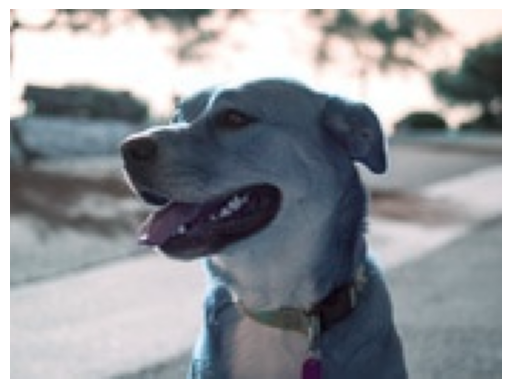

In [70]:
fig, ax = plt.subplots()
ax.imshow(image)
ax.axis('off')
plt.show()

In [71]:
image.shape

(130, 173, 3)

In [73]:
image[0][0]

array([199, 171, 164], dtype=uint8)

In [74]:
size = (32, 32)
resized_image_factor = cv2.resize(image, size)

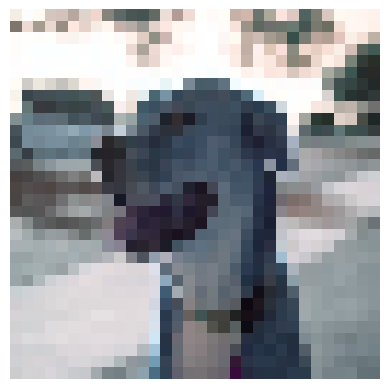

In [75]:
fig, ax = plt.subplots()
ax.imshow(resized_image_factor)
ax.axis('off')
plt.show()

In [76]:
resized_flattened_image_feature_vector = resized_image_factor.flatten()

In [77]:
len(resized_flattened_image_feature_vector)

3072

In [78]:
image_greyscale = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

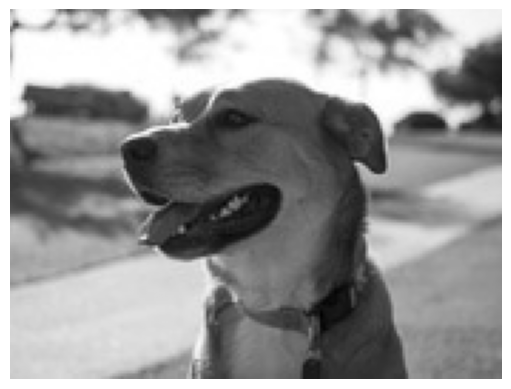

In [80]:
fig, ax = plt.subplots()
ax.imshow(image_greyscale, cmap='gray')
ax.axis('off')
plt.show()

In [82]:
image_greyscale.shape

(130, 173)

In [84]:
image_greyscale[0][0]

np.uint8(172)

In [85]:
import numpy as np

In [86]:
np.expand_dims(image_greyscale, axis=2)

array([[[172],
        [206],
        [237],
        ...,
        [241],
        [242],
        [242]],

       [[196],
        [209],
        [235],
        ...,
        [242],
        [243],
        [242]],

       [[208],
        [209],
        [229],
        ...,
        [242],
        [242],
        [241]],

       ...,

       [[207],
        [203],
        [202],
        ...,
        [112],
        [113],
        [112]],

       [[203],
        [205],
        [206],
        ...,
        [115],
        [119],
        [116]],

       [[202],
        [203],
        [205],
        ...,
        [118],
        [123],
        [120]]], shape=(130, 173, 1), dtype=uint8)

In [87]:
np.expand_dims(image_greyscale, axis=2).shape

(130, 173, 1)

In [89]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
gender,100.0,5.200000e-01,0.502117,0.000000,0.000000,1.000000,1.000000,1.000000
math score,100.0,-1.569318e-16,1.005038,-2.287338,-0.646391,-0.075626,0.637829,2.421468
reading score,100.0,-1.088019e-16,1.005038,-3.293112,-0.690155,0.053547,0.667101,2.433392
writing score,100.0,8.881784e-17,1.005038,-3.141031,-0.756535,0.110554,0.688613,2.278277
race/ethnicity_group A,100.0,1.100000e-01,0.314466,0.000000,0.000000,0.000000,0.000000,1.000000
race/ethnicity_group B,100.0,2.700000e-01,0.446196,0.000000,0.000000,0.000000,1.000000,1.000000
race/ethnicity_group C,100.0,3.200000e-01,0.468826,0.000000,0.000000,0.000000,1.000000,1.000000
race/ethnicity_group D,100.0,2.000000e-01,0.402015,0.000000,0.000000,0.000000,0.000000,1.000000
race/ethnicity_group E,100.0,1.000000e-01,0.301511,0.000000,0.000000,0.000000,0.000000,1.000000
parental level of education_associate's degree,100.0,1.500000e-01,0.358870,0.000000,0.000000,0.000000,0.000000,1.000000
